# Predicted comments 

This notebook implements a series of different ML model out of the box, to try and predict the number of comments left on planning applications based on a set of variables. 

First I combine my datasets to get all my variables in one dataframe. The datasets are: 
- Comments dataset - used to group the number of comments on each application 
- application_df - this is the lsit of application id's used for webscraping - I use this to ensure consistent matching 
- pld_df - this is the dataset direct from the planning london datahub (via ElasticSearch)

After some pre-processing I then use ML models to look at the relationship between different variables and the number of comments left. 

The models used are: 
- Regression 
- Random forest 
- XGBoost 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score

import xgboost as xgb

import statsmodels.api as sm
import statsmodels.formula.api as smf

from database.comments import Comments

import sys
sys.path.append('../functions')
import preprocessing_fncs as ppf
from elastic_search_fncs import ElasticSearchFncs

## Load the datasets

Comments dataset - webscraped free-text comments. 

In [2]:
# Comments dataset
cs = Comments(env="dev")
comment_df = cs.read_all().copy()
comment_df = ppf.format_borough(comment_df, 'council')

comment_df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,-0.248590,some residents in have raised concerns about t...,E09000003,-0.084598
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,-0.189180,I am writing to express my strong objection to...,E09000003,-0.362558
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,-0.252985,"1. From the plans and elevations, the proposed...",E09000003,-0.424556
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,-0.252440,we dont want this houses at the bottom of our ...,E09000003,-0.365758
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,-0.276780,I am not objecting to this planning applicatio...,E09000005,0.019409


Applications dataset - list of applciation IDs used for webscraping. 

In [3]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

application_df = ppf.format_df(application_df, 'borough')

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


In [4]:
# format the application_df by adding comment counts
app_count = comment_df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

In [5]:
# Run the formatting functions 
application_df = ppf.format_df(application_df)

# TODO: check logic of this function - I think soem columns are empty 
# application_df = ppf.create_decision_outcomes(application_df, completion_date_col_name='decision_date')

In [6]:
# Check for non-unique 'lpa_app_no' values
# Some boroughs use the same application number format, so there may be duplicates across boroughs

# return application_df where 'lpa_app_no' is not unique
application_df[application_df.duplicated(subset=['lpa_app_no'], keep=False)].sort_values(by=['lpa_app_no'])

,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description,comment_count
1626,21/03029/FUL,NaT,NaT,Lambeth,8,NaN,663.00000,0.036199,PP-10065540,1.000219e+11,Approved,Approved,Kingsmead Road,NaN,89,GEOMETRYCOLLECTION (POLYGON ((531174.583375 17...,"polygon=linearring(x=[-0.11412889999999999, -0...",Demolition of existing house and erection of a...,41
2069,21/03029/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-10446127,1.009488e+10,Refused,Refused,Romford Road,Development Site Rear Of 865,NaN,GEOMETRYCOLLECTION (POLYGON ((542572.0 185871....,"polygon=linearring(x=[0.055038, 0.055067, 0.05...",Demolition of existing storage structure and t...,41
872,22/02530/FUL,NaT,NaT,Newham,1,NaN,100.00000,0.010000,PP-11642396,4.600363e+07,Commenced,Approved,NaN,144 Barking Road,NaN,NaN,NaN,NaN,8
1785,22/02530/FUL,NaT,NaT,Lambeth,1,NaN,155.00000,0.012903,PP-11388806,1.000233e+11,Commenced,Approved,Streatham Vale,NaN,29,GEOMETRYCOLLECTION (POLYGON ((529676.209375 17...,"polygon=linearring(x=[-0.1365372, -0.1366097, ...",Retrospective change of use of the rear of the...,8
4453,22/02599/FUL,NaT,NaT,Lambeth,9,NaN,NaN,NaN,PP-11386341,1.000233e+11,Dismissed,Refused,Streatham High Road,NaN,"620, 626",GEOMETRYCOLLECTION (POLYGON ((530526.492875 17...,"polygon=linearring(x=[-0.1243947, -0.1246742, ...",Erection of three storey extension to create 9...,1
4781,22/02599/FUL,NaT,NaT,Newham,2,NaN,92.00000,0.021739,PP-11664621,1.000899e+10,Commenced,Approved,NaN,7 Prince Regent Lane,NaN,NaN,NaN,NaN,1
1560,23/00702/FUL,NaT,NaT,Lambeth,1,NaN,80.54000,0.037249,PP-11918401,2.000005e+11,Approved,Approved,Norwood High Street,NaN,121,GEOMETRYCOLLECTION (POLYGON ((532122.023375 17...,"polygon=linearring(x=[-0.10085329999999999, -0...","Refurbishment of the property, involving erect...",0
2949,23/00702/FUL,NaT,NaT,Newham,2,NaN,NaN,NaN,PP-11874782,1.000899e+10,Dismissed,Refused,High Street North,NaN,105,NaN,"polygon=linearring(x=[0.052142, 0.05214, 0.052...",Proposed two-storey extension to the rear of e...,0
411,23/01143/FUL,NaT,NaT,Newham,5,NaN,NaN,NaN,PP-12189160,1.000899e+10,Refused,Refused,Plashet Grove,NaN,167,NaN,"polygon=linearring(x=[0.042087, 0.042086, 0.04...","Redevelopment to form part-three, part- four s...",3
1439,23/01143/FUL,NaT,NaT,Lambeth,1,NaN,NaN,NaN,PP-11957518,1.000218e+11,Approved,Approved,NaN,66 Hatfields,NaN,NaN,NaN,NaN,3


Planning London Datahub - this the dataset with detailed tabular and geospatial info 

In [7]:
esf = ElasticSearchFncs()
esf.check_connection()

Connected to Elastic Search


In [8]:
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")

In [9]:
# Run the formatting functions on pld_df
pld_df = ppf.format_df(pld_df)
# Add column for hosuing type - based on logic regarding number of residential units
pld_df = ppf.add_housing_type(pld_df)

## Dataset processing 

### MERGE! datasets 

Merge and match the datasets from the different sources. 

In [10]:
application_df['lpa_app_no_borough'] = application_df['lpa_app_no'] + '_' + application_df['borough']
pld_df['lpa_app_no_borough'] = pld_df['lpa_app_no'] + '_' + pld_df['borough']

# to avoid duplciation afetr merging 
application_df.drop(columns=['decision_date', 'valid_date'], inplace=True)

In [11]:
df = pd.merge(application_df, pld_df[['housing_type', 'decision_date', 'valid_date', 'lpa_app_no_borough', 'actual_completion_date', 'wgs84_polygon.coordinates', 'polygon.coordinates', 'postcode']], left_on='lpa_app_no_borough', right_on='lpa_app_no_borough', how='left')

In [12]:
df.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5072
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3040
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4231
wgs84_polygon.coordinates       

In [13]:
df = ppf.create_decision_outcomes(df, completion_date_col_name='decision_date')

In [14]:
df.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5072
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3040
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4231
wgs84_polygon.coordinates       

In [15]:
df.columns

Index(['lpa_app_no', 'borough', 'total_no_proposed_residential_units',
       'total_no_affordable_units', 'site_area', 'habitable_rooms_density',
       'pp_id', 'uprn', 'status', 'decision', 'street_name', 'site_name',
       'site_number', 'polygon', 'wgs84_polygon', 'description',
       'comment_count', 'lpa_app_no_borough', 'housing_type', 'decision_date',
       'valid_date', 'actual_completion_date', 'wgs84_polygon.coordinates',
       'polygon.coordinates', 'postcode', 'outcome'],
      dtype='object')

In [16]:
# Check expected number of unique applications
print(df['lpa_app_no'].isin(application_df['lpa_app_no']).sum())
print(df['lpa_app_no_borough'].nunique())

5078
5077


In [17]:
# return the non unique value of df 'lpa_app_no_borough'
df[df.duplicated(subset=['lpa_app_no_borough'], keep=False)].sort_values(by=['lpa_app_no_borough'])

,lpa_app_no,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,...,comment_count,lpa_app_no_borough,housing_type,decision_date,valid_date,actual_completion_date,wgs84_polygon.coordinates,polygon.coordinates,postcode,outcome
2997,214465OPDFUL,Ealing,462,NaN,0.13,0.0,PP-09874188,12141006.0,Commenced,Approved,...,31,214465OPDFUL_Ealing,Mixed affordable housing,2023-05-03,2021-06-02,NaT,"[[[-0.259098, 51.522703], [-0.258842, 51.52264...",NaN,W3 6UL,Permitted
2998,214465OPDFUL,Ealing,462,NaN,0.13,0.0,PP-09874188,12141006.0,Commenced,Approved,...,31,214465OPDFUL_Ealing,Mixed affordable housing,2023-05-03,2021-06-02,NaT,NaN,NaN,W3 6UL,Permitted


In [18]:
# ok, the duplciates come from it being recorded in two different LPAs - Ealing and OPDC
# drop df duplicates
df = df.drop_duplicates(subset=['lpa_app_no_borough'], keep='first')

## Prep the datasets for modelling 

In [19]:
df_gpd = ppf.format_polygon(df)

/Users/bea/Documents/AI4CI/projects/comment_summariser/neighour_nlp/notebooks/../functions/preprocessing_fncs.py:362: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


In [20]:
df_gpd.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5071
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3039
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4230
wgs84_polygon.coordinates       

In [21]:
# add column with site area in m2
df = pd.merge(df, df_gpd[['lpa_app_no_borough', 'polygon_area_m2']], left_on='lpa_app_no_borough', right_on='lpa_app_no_borough', how='left')

In [22]:
df.head()

,lpa_app_no,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,...,lpa_app_no_borough,housing_type,decision_date,valid_date,actual_completion_date,wgs84_polygon.coordinates,polygon.coordinates,postcode,outcome,polygon_area_m2
0,24/02204/FUL,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,...,24/02204/FUL_Newham,Market housing,2025-03-25,2024-11-19,NaT,"[[[0.001716, 51.547651], [0.001703, 51.547679]...",NaN,E15 1JQ,Permitted,203.400814
1,25/0089,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,...,25/0089_Brent,Market housing,2025-03-24,2025-01-27,NaT,NaN,"[[[523522.7, 185196.2], [523522.95, 185196.2],...",None,Permitted,463.939275
2,24/1783,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,...,24/1783_Brent,Market housing,2025-03-24,2024-08-05,NaT,NaN,NaN,None,Permitted,NaN
3,25/00205/PRECOU,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,...,25/00205/PRECOU_Newham,Market housing,2025-03-25,2025-02-03,NaT,"[[[0.024619, 51.549902], [0.024663, 51.549928]...",NaN,E7 9BB,Permitted,279.960650
4,25/00181/PRECOU,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,...,25/00181/PRECOU_Newham,Market housing,2025-03-26,2025-01-30,NaT,"[[[0.020766, 51.546614], [0.020563, 51.546582]...",NaN,E7 9AE,Permitted,193.272377


In [23]:
# return how many na values there are in each column
df.isna().sum()

lpa_app_no                                0
borough                                   0
total_no_proposed_residential_units       0
total_no_affordable_units              5071
site_area                              4490
habitable_rooms_density                4490
pp_id                                     0
uprn                                      1
status                                   52
decision                                 56
street_name                            1687
site_name                              1704
site_number                            3039
polygon                                2485
wgs84_polygon                          2009
description                             660
comment_count                             0
lpa_app_no_borough                        0
housing_type                            122
decision_date                           123
valid_date                              122
actual_completion_date                 4230
wgs84_polygon.coordinates       

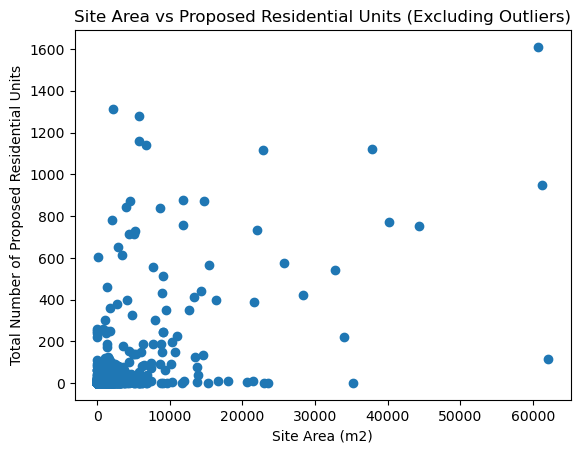

In [24]:
# scatter plot of polygon_area_m2 vs total_no_proposed_residential_units excluding outliers
# plt.scatter(df['polygon_area_m2'], df['total_no_proposed_residential_units'])
plt.scatter(df[df['polygon_area_m2'] < 100000]['polygon_area_m2'], df[df['polygon_area_m2'] < 100000]['total_no_proposed_residential_units'])
plt.xlabel('Site Area (m2)')
plt.ylabel('Total Number of Proposed Residential Units')
plt.title('Site Area vs Proposed Residential Units (Excluding Outliers)')
plt.show()

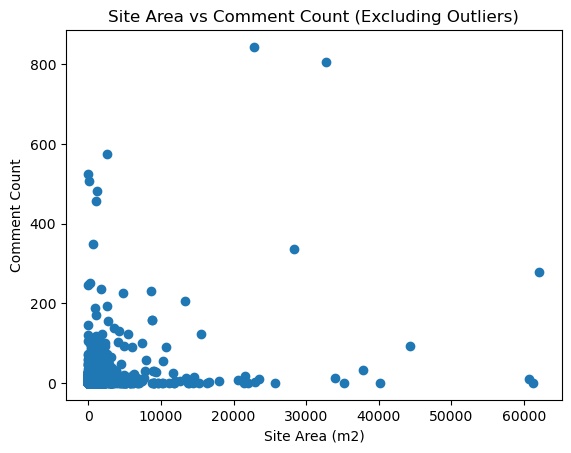

In [25]:
# scatter plot of polygon_area_m2 vs comment_count
plt.scatter(df[df['polygon_area_m2'] < 100000]['polygon_area_m2'], df[df['polygon_area_m2'] < 100000]['comment_count'])
plt.xlabel('Site Area (m2)')
plt.ylabel('Comment Count')
plt.title('Site Area vs Comment Count (Excluding Outliers)')
plt.show()

### Random Forest classifier 

Here implement a random forest classifier to predict if applications will receive comments (True/False), based on a set of variables. 

In [26]:
# add a binary column for comment truth - as this is something I want to try and predict 
df['comment_truth'] = np.where(df['comment_count'] > 0, 1, 0)
df.head()

,lpa_app_no,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,...,housing_type,decision_date,valid_date,actual_completion_date,wgs84_polygon.coordinates,polygon.coordinates,postcode,outcome,polygon_area_m2,comment_truth
0,24/02204/FUL,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,...,Market housing,2025-03-25,2024-11-19,NaT,"[[[0.001716, 51.547651], [0.001703, 51.547679]...",NaN,E15 1JQ,Permitted,203.400814,1
1,25/0089,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,...,Market housing,2025-03-24,2025-01-27,NaT,NaN,"[[[523522.7, 185196.2], [523522.95, 185196.2],...",None,Permitted,463.939275,0
2,24/1783,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,...,Market housing,2025-03-24,2024-08-05,NaT,NaN,NaN,None,Permitted,NaN,1
3,25/00205/PRECOU,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,...,Market housing,2025-03-25,2025-02-03,NaT,"[[[0.024619, 51.549902], [0.024663, 51.549928]...",NaN,E7 9BB,Permitted,279.960650,0
4,25/00181/PRECOU,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,...,Market housing,2025-03-26,2025-01-30,NaT,"[[[0.020766, 51.546614], [0.020563, 51.546582]...",NaN,E7 9AE,Permitted,193.272377,1


Predict whether an application will receive comments based on other features using random forest classifier

In [27]:
# define features 
features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type']
X = df[features]
# define target variable 
y = df['comment_truth']
# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['borough', 'housing_type'], drop_first=True)

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# make predictions
y_pred = rf.predict(X_test)

# evaluate model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[321 215]
 [187 293]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.60      0.61       536
           1       0.58      0.61      0.59       480

    accuracy                           0.60      1016
   macro avg       0.60      0.60      0.60      1016
weighted avg       0.61      0.60      0.60      1016



Evaluate feature importance in the Random Forest model

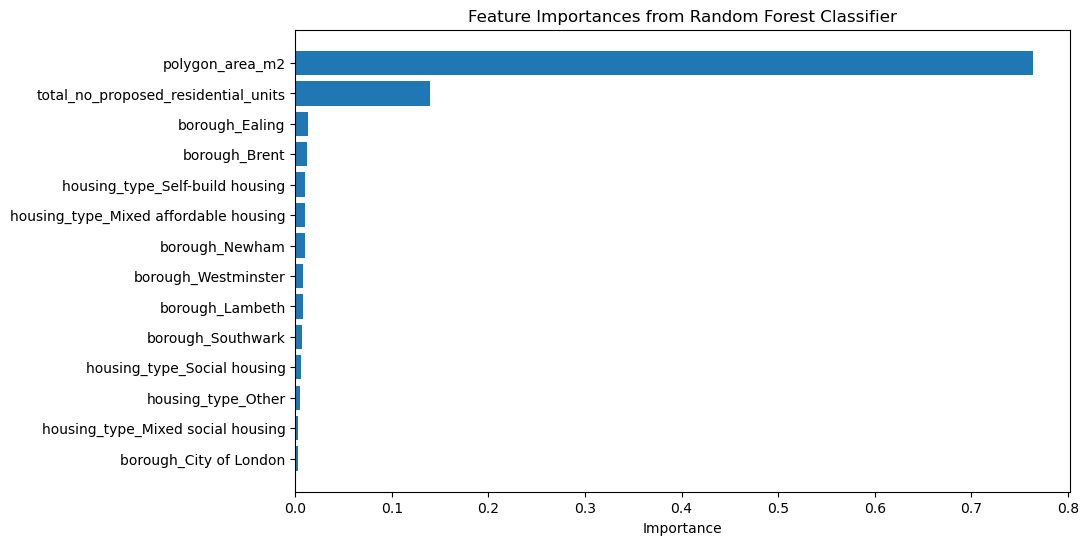

In [28]:
importances = rf.feature_importances_
feature_names = X.columns

# create a dataframe for feature importances
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
# sort the dataframe by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# plot feature importances
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest Classifier')
plt.gca().invert_yaxis()
plt.show()

In [29]:
df['outcome'].unique()

array(['Permitted', 'Superseded', 'Other', 'Withdrawn', 'Not Permitted'],
      dtype=object)

              precision    recall  f1-score   support

           0       0.33      0.08      0.12        13
           1       0.99      1.00      0.99      1003

    accuracy                           0.99      1016
   macro avg       0.66      0.54      0.56      1016
weighted avg       0.98      0.99      0.98      1016



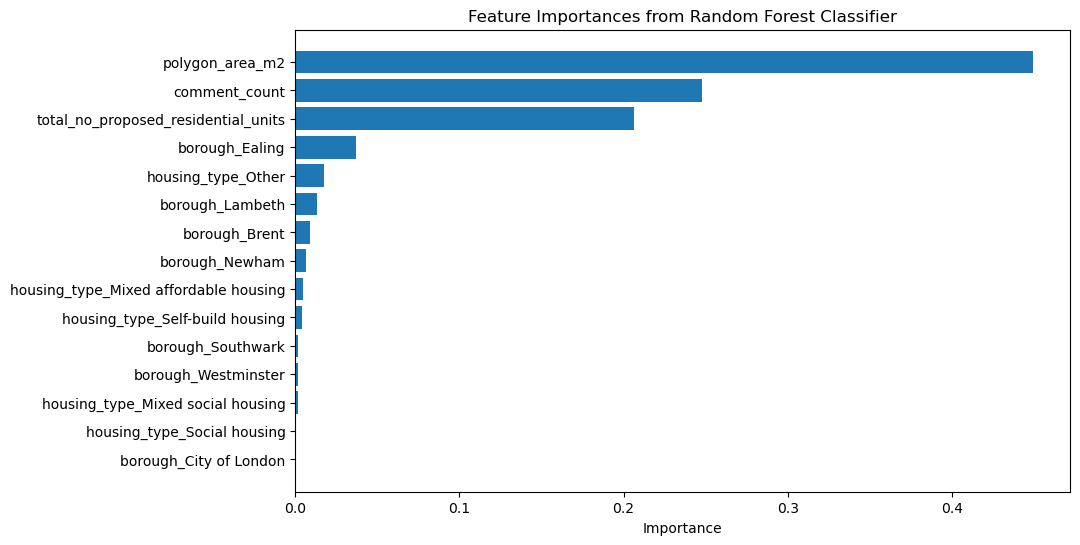

In [30]:
# predict whether an application will be approved based on other features using random forest classifier

# define features and target variable
features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type', 'comment_count']
X = df[features]

# y is 1 if 'Permitted' else 0
y = np.where(df['outcome'] == 'Permitted', 1, 0)
# one-hot encode categorical variables
X = pd.get_dummies(X, columns=['housing_type', 'borough'], drop_first=True)
# y = pd.get_dummies(y, drop_first=True)
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# train random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# make predictions
y_pred = rf.predict(X_test)
# evaluate model
# print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

importances = rf.feature_importances_
feature_names = X.columns
# create a dataframe for feature importances
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
# sort the dataframe by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
# plot feature importances
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest Classifier')
plt.gca().invert_yaxis()
plt.show()

## Regression model 

In [31]:
print("length of df:", len(df))
# drop rows with na values in relevant columns - as can't be inputs to the regression model
df_nona = df.dropna(subset=['comment_truth', 'borough', 'housing_type', 'total_no_proposed_residential_units', 'polygon_area_m2'])
print("length of df_nona:", len(df_nona))

length of df: 5077
length of df_nona: 4479


In [32]:
# Regression model using variables:
# X = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type'] 
# y = df['comment_truth']

features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type']

X = df_nona[features]
y = df_nona['comment_count']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the model and train
model = smf.ols('comment_count ~ C(borough) + C(housing_type) + total_no_proposed_residential_units + polygon_area_m2', data=df_nona).fit()

# make predictions
# X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test)
# evaluate model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 313.48652619451246
R-squared: -0.025040735396324676


In [33]:
# WITH LOG Y 

# Regression model using variables:
# X = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type'] 
# y = df['comment_truth']

df_nona['log_comment_count'] = np.log1p(df_nona['comment_count'])


features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type']

X = df_nona[features]
y = df_nona['comment_count']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the model and train
model = smf.ols(
    'log_comment_count ~ C(borough) + C(housing_type) + total_no_proposed_residential_units + polygon_area_m2',
    data=df_nona
).fit()

# make predictions
# X_test_sm = sm.add_constant(X_test)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)   # back-transform
# evaluate model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 317.8331820648832
R-squared: -0.039253465314786906


/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_73998/15769920.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nona['log_comment_count'] = np.log1p(df_nona['comment_count'])


In [34]:
# WEIGHTS

# Regression model using variables:
# X = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type'] 
# y = df['comment_truth']

df_nona['log_cc'] = np.log1p(df_nona['comment_count'])

features = ['total_no_proposed_residential_units', 'borough', 'polygon_area_m2', 'housing_type']

X = df_nona[features]
y = df_nona['comment_count']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# define the model and train
# model = smf.glm(
#     'comment_count ~ C(borough) + C(housing_type) + total_no_proposed_residential_units + polygon_area_m2',
#     data=df_nona,
#     family=sm.families.NegativeBinomial()
# ).fit()

model_log = smf.ols(
    'log_cc ~ C(borough) + C(housing_type) + total_no_proposed_residential_units + polygon_area_m2',
    data=df_nona
).fit()

test_df = df_nona.loc[X_test.index]
y_pred_log = model.predict(test_df)

# make predictions
# X_test_sm = sm.add_constant(X_test)
# y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
# evaluate model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 317.8331820648832
R-squared: -0.039253465314786906


/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_73998/1800440193.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nona['log_cc'] = np.log1p(df_nona['comment_count'])


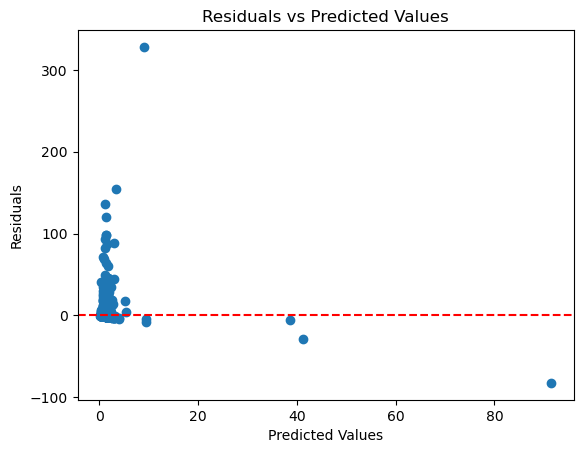

In [35]:
# plot model residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### XGBoost model 

In [36]:
# define features 
features = ['total_no_proposed_residential_units', 'outcome', 'borough', 'polygon_area_m2', 'housing_type']
X = df[features]
# define target variable 
y = df['comment_truth']

# Extract text features
cats = X.select_dtypes(exclude=np.number).columns.tolist()

# Convert to Pandas category
for col in cats:
   X[col] = X[col].astype('category')

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_73998/1916678217.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_73998/1916678217.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_73998/1916678217.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [37]:
X.dtypes

total_no_proposed_residential_units       int64
outcome                                category
borough                                category
polygon_area_m2                         float64
housing_type                           category
dtype: object

In [38]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create regression matrices - these are xgb.DMatrix objects
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [39]:
# Define hyperparameters
params = {"objective": "reg:squarederror", "tree_method": "hist"}

evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

n = 100
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
   evals=evals
)

[0]	train-rmse:0.47926	validation-rmse:0.48445
[1]	train-rmse:0.46619	validation-rmse:0.47783
[2]	train-rmse:0.45819	validation-rmse:0.47424
[3]	train-rmse:0.45165	validation-rmse:0.47295
[4]	train-rmse:0.44739	validation-rmse:0.47305
[5]	train-rmse:0.44390	validation-rmse:0.47408
[6]	train-rmse:0.44066	validation-rmse:0.47436
[7]	train-rmse:0.43776	validation-rmse:0.47386
[8]	train-rmse:0.43606	validation-rmse:0.47428
[9]	train-rmse:0.43266	validation-rmse:0.47484
[10]	train-rmse:0.43033	validation-rmse:0.47480
[11]	train-rmse:0.42973	validation-rmse:0.47483
[12]	train-rmse:0.42703	validation-rmse:0.47466
[13]	train-rmse:0.42609	validation-rmse:0.47559
[14]	train-rmse:0.42403	validation-rmse:0.47590
[15]	train-rmse:0.42380	validation-rmse:0.47601
[16]	train-rmse:0.42295	validation-rmse:0.47629
[17]	train-rmse:0.41955	validation-rmse:0.47695
[18]	train-rmse:0.41941	validation-rmse:0.47696
[19]	train-rmse:0.41842	validation-rmse:0.47724
[20]	train-rmse:0.41651	validation-rmse:0.47776
[2

In [40]:
results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=20
)

results.head()

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,0.477368,0.001121,0.486377,0.003331
1,0.463148,0.001689,0.480492,0.005988
2,0.453787,0.002115,0.477529,0.007822
3,0.447664,0.002727,0.477485,0.008938
4,0.442534,0.002716,0.477354,0.010104


In [41]:
best_rmse = results['test-rmse-mean'].min()

best_rmse

0.4773538867786045

## Simple neural network model 

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# Define features and target (already one-hot encoded)
features = ['total_no_proposed_residential_units', 'polygon_area_m2'] + \
           [col for col in X.columns if col.startswith('borough_') or col.startswith('housing_type_')]

X_nn = X[features].values
y_nn = y.values

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)

# Define the model
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Epoch 1/100


/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5246 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5249 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5249 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5249 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5249 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5249 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5249 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5249 - loss: nan - val_accuracy: 0.5043 - val_loss: nan
Epoch 9/100
102/102 ━━━━━━━━

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.